In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

Saving objects.jpg.jfif to objects.jpg.jfif


In [7]:
img = cv2.imread(img_path)
if img is None:
    print("Error: Image not loaded!")
    exit()
print("Processing:", img_path)

Processing: objects.jpg.jfif


In [8]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7,7), 0)

In [9]:
_, thresh = cv2.threshold(blur, 100, 255, cv2.THRESH_BINARY_INV)

In [10]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [11]:
count = 0
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 500:
        count += 1
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(img, f"W:{w} H:{h}", (x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

In [12]:
print("Total Objects Detected:", count)

Total Objects Detected: 12


(np.float64(-0.5), np.float64(569.5), np.float64(791.5), np.float64(-0.5))

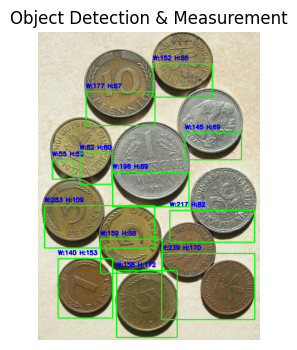

In [13]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.title("Object Detection & Measurement")
plt.axis('off')

In [7]:
import cv2
import numpy as np
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
img = cv2.imread(file_name)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 5)
circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,
    param1=50,
    param2=35,
    minRadius=20,
    maxRadius=120
)
one_rupee = 0
five_rupee = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :]:
        if r < 35:
            one_rupee += 1
        elif 35 <= r < 65:
            five_rupee += 1
print(f"5 rupee coins are {five_rupee}")

Saving objects.jpg.jfif to objects.jpg (6).jfif
5 rupee coins are 4
